# Library Import

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Import Dataset

In [2]:
data=pd.read_csv("election_results_2024.csv")
data

,Constituency,Const. No.,Leading Candidate,Leading Party,Trailing Candidate,Trailing Party,Margin,Status
0,AJMER,13,BHAGIRATH CHOUDHARY,Bharatiya Janata Party,RAMCHANDRA CHOUDHARY,Indian National Congress,329991,Result Declared
1,ALWAR,8,BHUPENDER YADAV,Bharatiya Janata Party,LALIT YADAV,Indian National Congress,48282,Result Declared
2,AMBALA,1,VARUN CHAUDHRY,Indian National Congress,BANTO KATARIA,Bharatiya Janata Party,49036,Result Declared
3,ANANTNAG-RAJOURI,3,MIAN ALTAF AHMAD,Jammu & Kashmir National Conference,MEHBOOBA MUFTI,Jammu & Kashmir Peoples Democratic Party,281794,Result Declared
4,ARAKKONAM,7,S JAGATHRATCHAKAN,Dravida Munnetra Kazhagam,L VIJAYAN,All India Anna Dravida Munnetra Kazhagam,306559,Result Declared
...,...,...,...,...,...,...,...,...
538,Wardha,8,AMAR SHARADRAO KALE,Nationalist Congress Party – Sharadchandra Pawar,RAMDAS CHANDRABHAN TADAS,Bharatiya Janata Party,81648,Result Declared
539,Wayanad,4,RAHUL GANDHI,Indian National Congress,ANNIE RAJA,Communist Party of India,364422,Result Declared
540,West Delhi,6,KAMALJEET SEHRAWAT,Bharatiya Janata Party,MAHABAL MISHRA,Aam Aadmi Party,199013,Result Declared
541,Yavatmal- Washim,14,SANJAY UTTAMRAO DESHMUKH,Shiv Sena (Uddhav Balasaheb Thackrey),RAJSHRITAI HEMANT PATIL (MAHALLE),Shiv Sena,94473,Result Declared


# Party with Highest and Lowest margin of victory

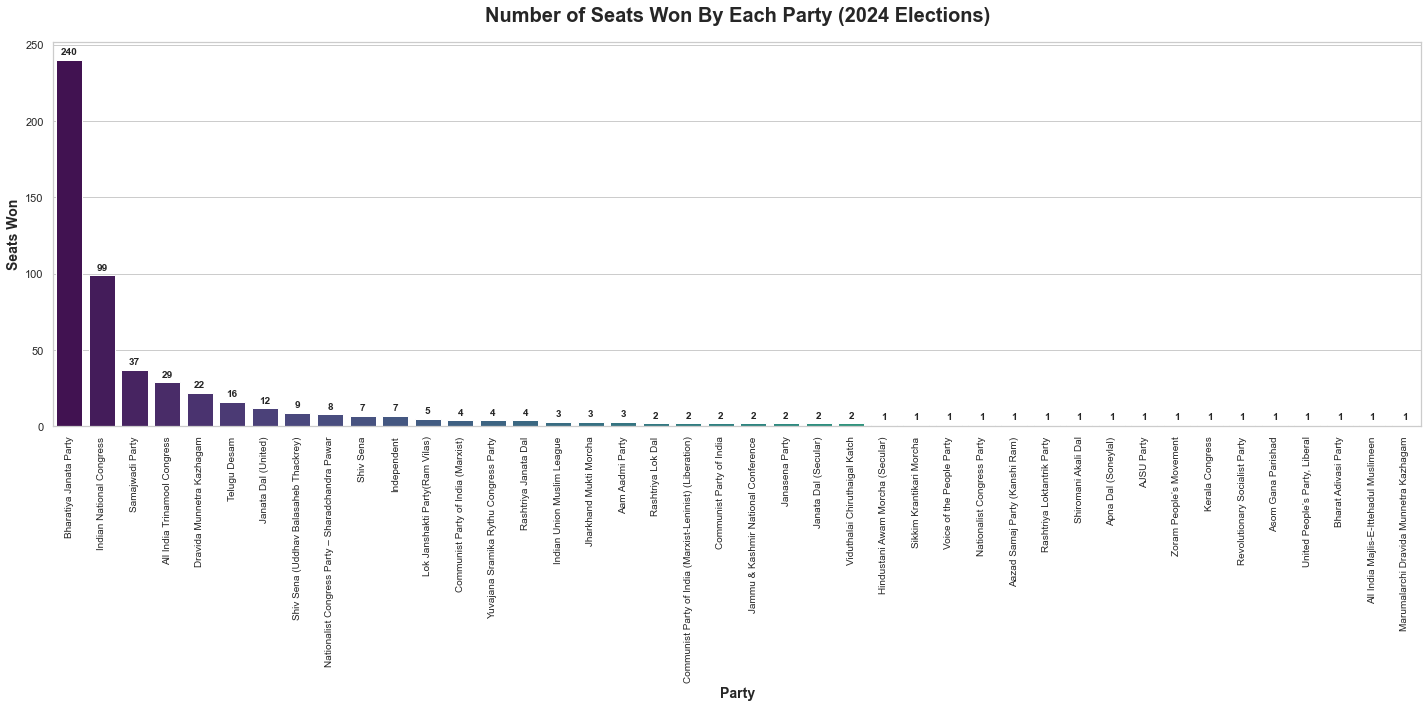

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
data = pd.read_csv('election_results_2024.csv')

# Calculate counts for seats won
seats_won = data['Leading Party'].value_counts()

# Identify highest and lowest
leading_party_highest_votes = seats_won.idxmax()
leading_party_lowest_votes = seats_won.idxmin()

# Set style for the visual appeal
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(20, 10))
ax = sns.barplot(x=seats_won.index, y=seats_won.values, palette='viridis', hue=seats_won.index, dodge=False)

# Add data labels on top of bars
for i, v in enumerate(seats_won.values):
    ax.text(i, v + 2, str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

# Remove the legend to avoid 'Rectangle' errors and clutter
if ax.get_legend() is not None:
    ax.get_legend().remove()

# Formatting
plt.title('Number of Seats Won By Each Party (2024 Elections)', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Party', fontsize=14, fontweight='bold')
plt.ylabel('Seats Won', fontsize=14, fontweight='bold')
plt.xticks(rotation=90, fontsize=10)
plt.tight_layout()

# Save and Show
plt.savefig('election_graph.png')
plt.show()

print(f"Graph generated successfully. Highest: {leading_party_highest_votes}")

# Get the votes for Rahul gandhi, Narendra Modi, Amit Shah

Graph generated successfully. Highest: Bharatiya Janata Party


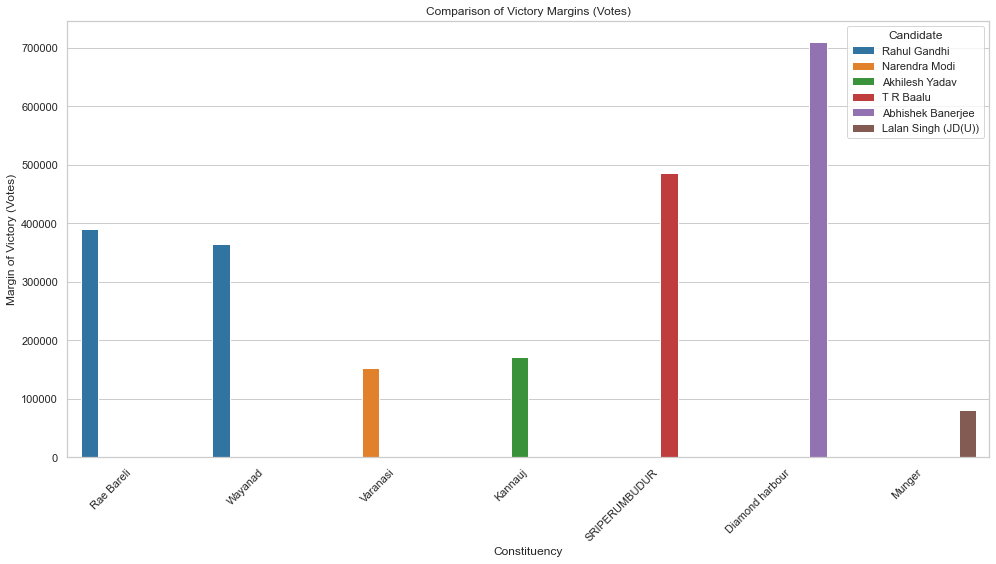

In [4]:
# Data Cleaning: Margin must be converted to numeric (critical step)
data['Margin'] = data['Margin'].astype(str).str.replace(',', '', regex=False).str.replace('-', '0', regex=False)
data['Margin'] = pd.to_numeric(data['Margin'], errors='coerce')
data = data.dropna(subset=['Margin'])

# Define all candidates and their display names
candidates = {
    "RAHUL GANDHI": "Rahul Gandhi",
    "NARENDRA MODI": "Narendra Modi",
    "AKHILESH YADAV": "Akhilesh Yadav",
    "T R BAALU": "T R Baalu",
    "ABHISHEK BANERJEE": "Abhishek Banerjee",
    "RAJIV RANJAN SINGH ALIAS LALAN SINGH": "Lalan Singh (JD(U))"
}

plot_data_list = []

for candidate_csv_name, candidate_display_name in candidates.items():
    entries = data[data['Leading Candidate'] == candidate_csv_name]
    
    if not entries.empty:
        # Handle candidates with multiple entries (like Rahul Gandhi) or single entries
        if len(entries) > 1:
            for index, row in entries.iterrows():
                plot_data_list.append({
                    'Candidate': candidate_display_name,
                    'Constituency': row['Constituency'],
                    'Votes': row['Margin']
                })
        else:
            plot_data_list.append({
                'Candidate': candidate_display_name,
                'Constituency': entries['Constituency'].values[0],
                'Votes': entries['Margin'].values[0]
            })

data_to_plot = pd.DataFrame(plot_data_list)

# Plot the Comparison
plt.figure(figsize=(14, 8))
sns.barplot(data=data_to_plot, x="Constituency", y="Votes", hue="Candidate", palette="tab10")
plt.title('Comparison of Victory Margins (Votes)')
plt.xlabel('Constituency')
plt.ylabel('Margin of Victory (Votes)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Candidate', loc='upper right')
plt.tight_layout()
plt.show()
plt.savefig('star_candidates_comparison_plot.png')
plt.close()

# Highest and Lowest Margin Entry of votes 

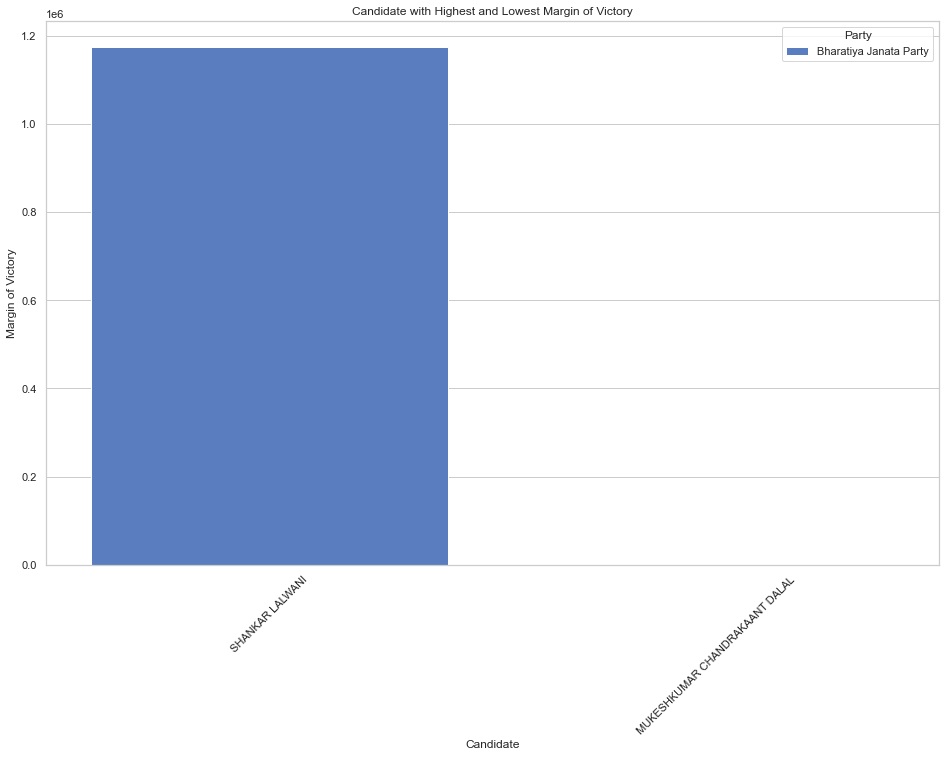

In [5]:
highest_margin_entry = data.loc[data['Margin'].idxmax()]
lowest_margin_entry = data.loc[data['Margin'].idxmin()]

#combine the data
data_to_plot = pd.DataFrame({
    'Candidate': [highest_margin_entry['Leading Candidate'], lowest_margin_entry['Leading Candidate']],
    'Party': [highest_margin_entry['Leading Party'], lowest_margin_entry['Leading Party']],
    'Margin': [highest_margin_entry['Margin'], lowest_margin_entry['Margin']]
})

#Plot the Above data
plt.figure(figsize=(16,10))
sns.barplot(data=data_to_plot, x="Candidate", y="Margin", hue="Party",palette="muted")
plt.title('Candidate with Highest and Lowest Margin of Victory')
plt.xlabel('Candidate')
plt.ylabel('Margin of Victory')
plt.xticks(rotation=45)
plt.show()


# Votes Distribution By Party

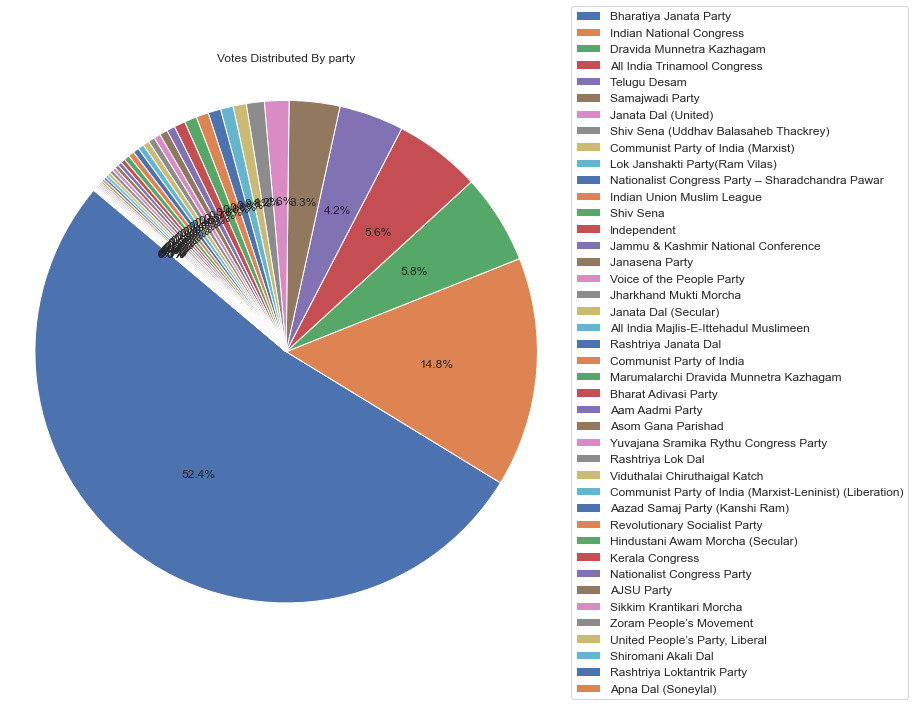

In [6]:
party_votes = data.groupby('Leading Party')['Margin'].sum().sort_values(ascending=False)

#Plot by Pie Chart
plt.figure(figsize=(10,10))
wedges, texts, autotexts = plt.pie(party_votes,labels=None, autopct='%1.1f%%', startangle=140, wedgeprops=dict(edgecolor='w'))
plt.title('Votes Distributed By party', pad=20)
plt.axis('equal')
plt.legend(labels=party_votes.index,loc='center left', bbox_to_anchor=(1,0.5), fontsize='medium')
plt.show()

# 1. LOGISTIC REGRESSION MODEL

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [8]:
data = data.dropna() #drops the rows with missing values if there are any.

In [9]:
import warnings
warnings.filterwarnings("ignore")

In [10]:
#sets the value 1 if It is Bharatiya Janata Party otherwise it shows 0 for any other party
data['Target'] = data['Leading Party'].apply(lambda x: 1 if 'Bharatiya Janata Party' in x else 0)

In [11]:
data['Target']

0      1
1      1
2      0
3      0
4      0
      ..
538    0
539    0
540    1
541    0
542    0
Name: Target, Length: 542, dtype: int64

In [12]:
#label Encoding
le = LabelEncoder()
data['Leading Party Enc'] = le.fit_transform(data['Leading Party'])
data['Trailing Party Enc'] = le.fit_transform(data['Trailing Party'])

In [13]:
X = data[['Const. No.', 'Margin', 'Leading Party Enc', 'Trailing Party Enc']]
y = data['Target']

In [14]:
#Split the data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
#Create the Instance of Logistic Regression Model
model = LogisticRegression()
model

LogisticRegression()

In [16]:
model.fit(X_train, y_train)

LogisticRegression()

In [17]:
y_pred = model.predict(X_test)

In [18]:
acc1 = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

In [19]:
print((f"\n Accuracy: {acc1*100:.2f}%"))
print("\n Confusion Matrix:\n",cr)
print("\n Classification Report:\n", cr)


 Accuracy: 80.73%

 Confusion Matrix:
               precision    recall  f1-score   support

           0       0.92      0.77      0.84        71
           1       0.67      0.87      0.76        38

    accuracy                           0.81       109
   macro avg       0.80      0.82      0.80       109
weighted avg       0.83      0.81      0.81       109


 Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.77      0.84        71
           1       0.67      0.87      0.76        38

    accuracy                           0.81       109
   macro avg       0.80      0.82      0.80       109
weighted avg       0.83      0.81      0.81       109



# 2.KNN MODEL

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore") # Suppress warnings related to feature engineering

# --- 1. Load Data and Clean Margin Column ---
data = pd.read_csv("election_results_2024.csv")

# Clean 'Margin': replace non-numeric characters (like ',') and '-' with '0', then convert to numeric
data['Margin'] = data['Margin'].astype(str).str.replace(',', '', regex=False).str.replace('-', '0', regex=False)
data['Margin'] = pd.to_numeric(data['Margin'], errors='coerce')
# Drop the row that contained '-' (Uncontested status) which is now 0 and likely has missing trailing party
data = data[data['Status'] != 'Uncontested'].copy()


# --- 2. Feature Engineering and Encoding ---
le = LabelEncoder() # Initialize LabelEncoder (Fix for NameError: le not defined)

# Define Encoded Features (Fix for missing columns)
data['Leading Party Enc'] = le.fit_transform(data['Leading Party'])
data['Trailing Party Enc'] = le.fit_transform(data['Trailing Party'])

# Calculate median and define Target Variable
median_margin = data['Margin'].median()
# Shows the value 1 if the margin is greater than median otherwise it shows 0.
data['HighMargin'] = np.where(data['Margin'] > median_margin, 1, 0)

# Encode Status and create Margin Ratio
data['Status Enc'] = le.fit_transform(data['Status'])
data['MarginRatio'] = data['Margin'] / data['Margin'].max()


# --- 3. Model Setup and Scaling ---
X = data[['Const. No.', 'Leading Party Enc', 'Trailing Party Enc', 'Status Enc', 'MarginRatio']]
y = data['HighMargin']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- 4. Hyperparameter Tuning (GridSearch) ---
param_grid = {
    'n_neighbors': list(range(3, 31, 2)),  # odd K values
    'weights': ['uniform', 'distance'],    # weight by distance
    'metric': ['euclidean', 'manhattan']   # different distance measures
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

best_knn = grid.best_estimator_
best_params = grid.best_params_

# --- 5. Evaluation (Fix for NameError: y_pred not defined) ---
y_pred = best_knn.predict(X_test_scaled) # Correctly generate predictions

acc2 = accuracy_score(y_test, y_pred)

print(" Best Parameters Found:", best_params)
print(f"\n KNN Accuracy: {acc2*100:.2f}%")
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))

 Best Parameters Found: {'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'distance'}

 KNN Accuracy: 90.83%

 Confusion Matrix:
 [[55  2]
 [ 8 44]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.96      0.92        57
           1       0.96      0.85      0.90        52

    accuracy                           0.91       109
   macro avg       0.91      0.91      0.91       109
weighted avg       0.91      0.91      0.91       109



In [21]:
#Shows the value 1 if the margin is less than median otherwise it shows 0.
data['HighMargin'] = data['Margin'].apply(lambda x: 1 if x > median_margin else 0)

In [22]:
data["HighMargin"]

0      1
1      0
2      0
3      1
4      1
      ..
538    0
539    1
540    1
541    0
542    0
Name: HighMargin, Length: 542, dtype: int64

In [23]:
data['Status Enc'] = le.fit_transform(data['Status'])
data['Status Enc']

0      0
1      0
2      0
3      0
4      0
      ..
538    0
539    0
540    0
541    0
542    0
Name: Status Enc, Length: 542, dtype: int32

In [24]:
data['MarginRatio'] = data['Margin'] / data['Margin'].max()
data['MarginRatio']

0      0.280821
1      0.041088
2      0.041729
3      0.239806
4      0.260881
         ...   
538    0.069482
539    0.310122
540    0.169360
541    0.080396
542    0.039306
Name: MarginRatio, Length: 542, dtype: float64

In [25]:
# Selecting the target feature and independent feature
X = data[['Const. No.', 'Leading Party Enc', 'Trailing Party Enc', 'Status Enc', 'MarginRatio']]
y = data['HighMargin']

In [26]:
# Selecting the target feature and independent feature
X = data[['Const. No.', 'Leading Party Enc', 'Trailing Party Enc', 'Status Enc', 'MarginRatio']]
y = data['HighMargin']
#Spliting the data into the training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#Creating the instance of the standard scaler
scaler = StandardScaler()
scaler
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Hyperparameter tuning using GridSearchCV
param_grid = {
    'n_neighbors': list(range(3, 31, 2)),  # odd K values
    'weights': ['uniform', 'distance'],    # weight by distance
    'metric': ['euclidean', 'manhattan']   # different distance measures
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

# Best model and parameters
best_knn = grid.best_estimator_
best_params = grid.best_params_
print(" Best Parameters Found:", best_params)
acc2 = accuracy_score(y_test, y_pred)
print(f"\n KNN Accuracy: {acc2*100:.2f}%")
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))

 Best Parameters Found: {'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'distance'}

 KNN Accuracy: 90.83%

 Confusion Matrix:
 [[55  2]
 [ 8 44]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.96      0.92        57
           1       0.96      0.85      0.90        52

    accuracy                           0.91       109
   macro avg       0.91      0.91      0.91       109
weighted avg       0.91      0.91      0.91       109



In [27]:
#Creating the instance of the standard scaler
scaler = StandardScaler()
scaler

StandardScaler()

In [28]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
# Hyperparameter tuning using GridSearchCV
param_grid = {
    'n_neighbors': list(range(3, 31, 2)),  # odd K values
    'weights': ['uniform', 'distance'],    # weight by distance
    'metric': ['euclidean', 'manhattan']   # different distance measures
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

# Best model and parameters
best_knn = grid.best_estimator_
best_params = grid.best_params_
print(" Best Parameters Found:", best_params)


 Best Parameters Found: {'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'distance'}


In [30]:
acc2 = accuracy_score(y_test, y_pred)
print(f"\n KNN Accuracy: {acc2*100:.2f}%")
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))


 KNN Accuracy: 90.83%

 Confusion Matrix:
 [[55  2]
 [ 8 44]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.96      0.92        57
           1       0.96      0.85      0.90        52

    accuracy                           0.91       109
   macro avg       0.91      0.91      0.91       109
weighted avg       0.91      0.91      0.91       109



# Random Forest Classifier Model

In [31]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier

In [32]:
# Data Cleaning and Feature Engineering
data['Margin'] = (
    data['Margin'].astype(str).str.replace('-', '0', regex=False).str.replace(',', '', regex=False).astype(float)
)
data = data[data['Status'] != 'Uncontested'].copy()

In [33]:
# Create the binary target variable 'BJP_Won'
data['BJP_Won'] = np.where(data['Leading Party'] == 'Bharatiya Janata Party', 1, 0)

In [34]:
# One-Hot Encoding for 'Trailing Party'
# Use the top 10 trailing parties for one-hot encoding
top_trailing_parties = data['Trailing Party'].value_counts().nlargest(10).index.tolist()

In [35]:
def get_simplified_trailing_party(party):
    # Group parties outside the top 10 into 'Other'
    return party if party in top_trailing_parties else 'Other'
data['Simplified Trailing Party'] = data['Trailing Party'].apply(get_simplified_trailing_party)


In [36]:
# One-Hot Encode the simplified 'Trailing Party'
df_encoded = pd.get_dummies(data, columns=['Simplified Trailing Party'], drop_first=True, prefix='Trailing')

In [37]:
# Define Features (X) and Target (y)
feature_cols = ['Const. No.'] + [col for col in df_encoded.columns if col.startswith('Trailing_')]
X = df_encoded[feature_cols]
y = df_encoded['BJP_Won']

In [38]:
# --- 2. Split the Data (10% test size, consistent with the IPYNB) ---
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=21
)

In [39]:
# --- 3. Initialize, Fit, and Predict ---
rfc = RandomForestClassifier(random_state=21)
rfc.fit(X=x_train, y=y_train)
y_pred = rfc.predict(x_test)

In [40]:
# --- 4. Evaluate the Model ---
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, zero_division=0)
accuracy = accuracy_score(y_test, y_pred)

In [41]:
print("--- Model Evaluation Results (Using 'Const. No.' + 'Trailing Party' as Features) ---")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(report)
print(f"\nAccuracy Score: {accuracy:.4f}")

--- Model Evaluation Results (Using 'Const. No.' + 'Trailing Party' as Features) ---

Confusion Matrix:
[[27  2]
 [ 3 23]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92        29
           1       0.92      0.88      0.90        26

    accuracy                           0.91        55
   macro avg       0.91      0.91      0.91        55
weighted avg       0.91      0.91      0.91        55


Accuracy Score: 0.9091


# 4.Decision Tree Classifier Model

In [42]:
from sklearn.tree import DecisionTreeClassifier, plot_tree 

In [43]:
# Data Cleaning and Feature Engineering
data['Margin'] = (
    data['Margin']
    .astype(str)
    .str.replace('-', '0', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float))

In [44]:
data = data[data['Status'] != 'Uncontested'].copy()
data['BJP_Won'] = np.where(data['Leading Party'] == 'Bharatiya Janata Party', 1, 0)

In [45]:
# One-Hot Encoding for 'Trailing Party'
top_trailing_parties = data['Trailing Party'].value_counts().nlargest(10).index.tolist()
def get_simplified_trailing_party(party):
    return party if party in top_trailing_parties else 'Other'
data['Simplified Trailing Party'] = data['Trailing Party'].apply(get_simplified_trailing_party)
df_encoded = pd.get_dummies(data, columns=['Simplified Trailing Party'], drop_first=True, prefix='Trailing')

In [46]:
# Define Features (X) and Target (y)
feature_cols = ['Const. No.'] + [col for col in df_encoded.columns if col.startswith('Trailing_')]
X = df_encoded[feature_cols]
y = df_encoded['BJP_Won']

In [47]:
# 2. Split the Data
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=21
)

In [48]:
# 3. Initialize and Fit the Decision Tree
model = DecisionTreeClassifier(random_state=21, max_depth=3)
model.fit(X=x_train, y=y_train)

DecisionTreeClassifier(max_depth=3, random_state=21)

In [49]:
y_pred = model.predict(x_test)

In [50]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

In [51]:
# Classification Report
report = classification_report(y_test, y_pred, zero_division=0)

In [52]:
# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)

In [53]:
print("--- Decision Tree Classifier Evaluation Results (Max Depth 3) ---")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(report)
print(f"\nAccuracy Score: {accuracy:.4f}")

--- Decision Tree Classifier Evaluation Results (Max Depth 3) ---

Confusion Matrix:
[[28  1]
 [ 6 20]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89        29
           1       0.95      0.77      0.85        26

    accuracy                           0.87        55
   macro avg       0.89      0.87      0.87        55
weighted avg       0.88      0.87      0.87        55


Accuracy Score: 0.8727


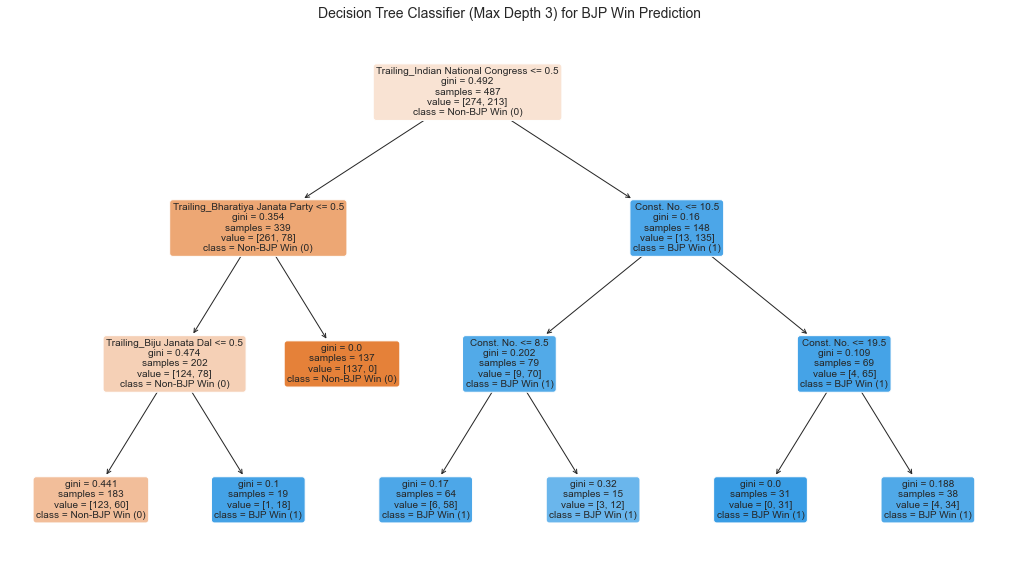

In [54]:
# --- 4. Visualization (Plotting in requested format) ---

plt.figure(figsize=(18, 10)) 
plot_tree(
    model,
    # Use X.columns for feature names (corrected from x.columns)
    feature_names=X.columns.tolist(), 
    # Use relevant class names (corrected from Diabetes/No Diabetes)
    class_names=['Non-BJP Win (0)', 'BJP Win (1)'], 
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Classifier (Max Depth 3) for BJP Win Prediction", fontsize=14)
plt.show()
plt.savefig('decision_tree_viz_final.png') 
plt.close()

In [55]:
y_pred = model.predict(x_test)

# --- 4. Evaluate the Model (Confusion Matrix and Report) ---

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Classification Report
report = classification_report(y_test, y_pred, zero_division=0)

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)

print("--- Decision Tree Classifier Evaluation Results (Max Depth 3) ---")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(report)
print(f"\nAccuracy Score: {accuracy:.4f}")


--- Decision Tree Classifier Evaluation Results (Max Depth 3) ---

Confusion Matrix:
[[28  1]
 [ 6 20]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89        29
           1       0.95      0.77      0.85        26

    accuracy                           0.87        55
   macro avg       0.89      0.87      0.87        55
weighted avg       0.88      0.87      0.87        55


Accuracy Score: 0.8727


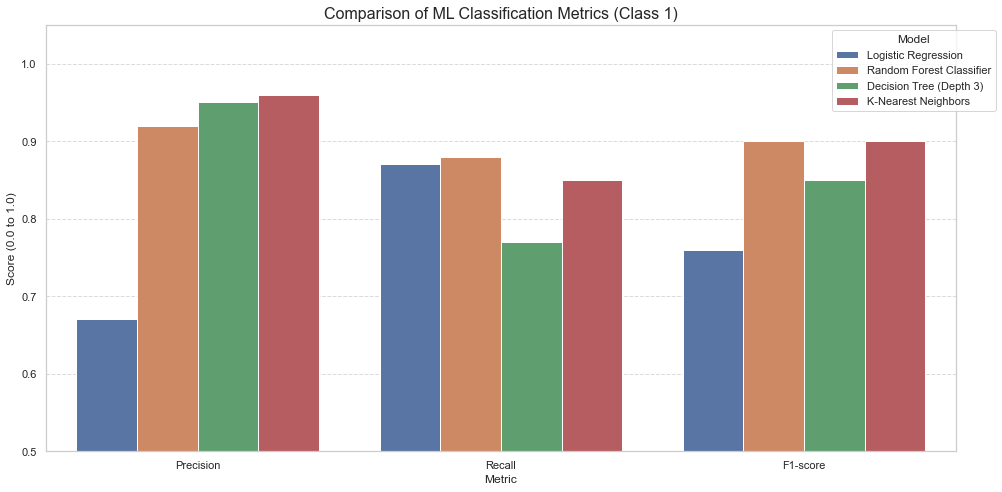

In [56]:
# Data collectedhe Classification Reports for Class 1 of each model.
#  In this comparison KNN predicts 'High Margin Win', others predict 'BJP Win'. 
data = {
    'Model': [
        'Logistic Regression', 
        'Random Forest Classifier', 
        'Decision Tree (Depth 3)',
        'K-Nearest Neighbors'
    ] * 3,
    'Metric': (
        ['Precision'] * 4 + 
        ['Recall'] * 4 + 
        ['F1-score'] * 4
    ),
    'Score': [
        # Precision (Class 1)
        0.67,  # LG (BJP Win)
        0.92,  # RFC (BJP Win)
        0.95,  # DTC (BJP Win)
        0.96,  # KNN (High Margin Win)
        
        # Recall (Class 1)
        0.87,  # LG (BJP Win)
        0.88,  # RFC (BJP Win)
        0.77,  # DTC (BJP Win)
        0.85,  # KNN (High Margin Win)
        
        # F1-score (Class 1)
        0.76,  # LG (BJP Win)
        0.90,  # RFC (BJP Win)
        0.85,  # DTC (BJP Win)
        0.90   # KNN (High Margin Win)
    ],
    'Target': (
        ['BJP Win'] * 3 + 
        ['High Margin']
    ) * 3
}

df_metrics = pd.DataFrame(data)

# Create the Grouped Bar Plot
plt.figure(figsize=(14, 7))
sns.barplot(
    data=df_metrics, 
    x='Metric', 
    y='Score', 
    hue='Model', 
    palette='deep'
)

# Add title and labels
plt.title('Comparison of ML Classification Metrics (Class 1)', fontsize=16)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.xlabel('Metric', fontsize=12)
plt.ylim(0.5, 1.05)
plt.legend(title='Model', loc='upper right', bbox_to_anchor=(1.05, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# In a notebook environment, you would use plt.show()
# For generating an image file, use plt.savefig()
plt.savefig('ml_all_metrics_comparison_plot.png') 
plt.close()

In [57]:
import tabulate
print("Tabulate is successfully installed.")

Tabulate is successfully installed.


In [58]:
import pandas as pd
import numpy as np

# Data extracted from the Classification Reports for Class 1 (BJP Win)
# We exclude KNN as it predicts a different target (High Margin Win).
summary_data = {
    'Model': ['Logistic Regression', 'Random Forest Classifier', 'Decision Tree (Depth 3)'],
    'Precision': [0.67, 0.92, 0.95],
    'Recall': [0.87, 0.88, 0.77],
    'F1-score': [0.76, 0.90, 0.85],
    'Support': [38, 26, 26] 
}

df_summary = pd.DataFrame(summary_data)

# Find the model with the highest F1-score, as this represents the best balance
best_model_row = df_summary.loc[df_summary['F1-score'].idxmax()]

# Extract the recommended model and its F1-score
recommended_model = best_model_row['Model']
best_f1_score = best_model_row['F1-score']
best_precision = best_model_row['Precision']
best_recall = best_model_row['Recall']


print("--- ML Model Recommendation for 'BJP Win' Prediction Task ---")
print("\nSummary of Model Performance (Class 1: BJP Win):")
print(df_summary.to_markdown(index=False, numalign="left", stralign="left"))

print(f"\nRecommendation: The **{recommended_model}** model is recommended.")

--- ML Model Recommendation for 'BJP Win' Prediction Task ---

Summary of Model Performance (Class 1: BJP Win):
| Model                    | Precision   | Recall   | F1-score   | Support   |
|:-------------------------|:------------|:---------|:-----------|:----------|
| Logistic Regression      | 0.67        | 0.87     | 0.76       | 38        |
| Random Forest Classifier | 0.92        | 0.88     | 0.9        | 26        |
| Decision Tree (Depth 3)  | 0.95        | 0.77     | 0.85       | 26        |

Recommendation: The **Random Forest Classifier** model is recommended.


In [66]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
import requests
import os

# --- FIX FOR BLANK OUTPUTS IN VS CODE ---
# This forces the map to open in your system's web browser
pio.renderers.default = "browser" 

# 1. LOAD GEOJSON
geojson_url = "https://gist.githubusercontent.com/planemad/1e2b63f6b9806970db749f19980ffd25/raw/india_pc_2024_simplified.geojson"
india_geojson = requests.get(geojson_url).json()

# 2. LOAD YOUR DATA
try:
    df = pd.read_csv("election_results_2024.csv")
except:
    print("⚠️ CSV not found. Using demo data...")
    all_pcs = [f['properties']['pc_name'] for f in india_geojson['features']]
    df = pd.DataFrame({
        'Constituency': all_pcs,
        'Leading Party': ['Bharatiya Janata Party', 'Indian National Congress', 'Samajwadi Party'] * (len(all_pcs)//3 + 1)
    })

# 3. CREATE THE MAP
fig = px.choropleth_mapbox(
    df,
    geojson=india_geojson,
    locations='Constituency',
    featureidkey="properties.pc_name",
    color='Leading Party',
    color_discrete_map={
        "Bharatiya Janata Party": "#FF9933", 
        "Indian National Congress": "#19AAED",
        "Samajwadi Party": "#228B22"
    },
    mapbox_style="carto-positron",
    zoom=3.8,
    center={"lat": 22.5, "lon": 82.0},
    opacity=0.7,
    title="<b>India Election 2024: Full Constituency Map</b>"
)

fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0}, height=800)

# 4. SAVE AS HTML AND OPEN
# This creates a file you can share or keep forever
file_name = "india_election_map_2024.html"
fig.write_html(file_name)

print(f"✅ Map saved successfully as: {os.path.abspath(file_name)}")
print("🚀 Opening map in your web browser now...")

# 5. SHOW IN BROWSER
fig.show()

✅ Map saved successfully as: C:\Users\s\Desktop\ADVANCED CODE\india_election_map_2024.html
🚀 Opening map in your web browser now...
